# 15 — Tap triplet-loss embedder (v1)

Same structure as `14_gesture_embedder.ipynb` (fixed-identity-set AUC-vs-k,
negative control, multi-seed stability, permutation feature importance,
checkpoint caching), retargeted to the tap modality.

**Baseline note**: `BASELINE_AUC` below is pulled from `trust_window_results.csv`'s
tap / `fixed_across_k` rows, generated AFTER the evaluation harness's
cohort-normalisation fix -- confirmed present in `evaluate_trust_windows.py`
this session -- and AFTER `_stats.py`'s `tailmean` suffix was added, tested
against real data, found redundant (0.92-0.998 correlated with existing
`p95`/`std` columns for every family it survived filtering in), and reverted.
So this notebook's feature set is the standard 9-suffix set, same as gesture's.

In [ ]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

%config InlineBackend.close_figures = False

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
tap_path = find(str(MOD_DIR / 'tap_windows.parquet'), 'tap_windows.parquet',
                 '/mnt/user-data/uploads/tap_windows.parquet')
splits_path = find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv',
                    '/mnt/user-data/uploads/identity_splits.csv')

OUT_DIR = Path(find('data/processed/tap_embedder', '../data/processed/tap_embedder', '.'))
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
print(f"Outputs will be written to: {OUT_DIR.resolve()}")

df = pd.read_parquet(tap_path)
splits = pd.read_csv(splits_path)
df = df.merge(splits[['sessionId', 'role']], on='sessionId', how='inner')
print(f"tap windows: {df.shape}, sessions matched to splits: {df['sessionId'].nunique()}")
print(df.groupby('role').size())

Outputs will be written to: /Users/will/Documents/BBDC-Prototype-2-Research/ML-notebooks
tap windows: (3106, 96), sessions matched to splits: 89
role
enrol     552
probe     348
train    2206
dtype: int64


## 1. Feature preparation

In [2]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
coverage = df[feats].notna().mean()
feats = coverage[coverage >= 0.5].index.tolist()
print(f"{len(feats)} features used")

train_df = df[df['role'] == 'train']
imputer = SimpleImputer(strategy='median').fit(train_df[feats])
scaler = StandardScaler().fit(imputer.transform(train_df[feats]))

def embed_input(sub):
    return scaler.transform(imputer.transform(sub[feats])).astype(np.float32)

X_all = embed_input(df)
y_all = df['participantId'].values
role_all = df['role'].values
print(f"X_all: {X_all.shape}")

def data_fingerprint():
    h = hashlib.sha256()
    h.update(X_all.tobytes()); h.update(str(sorted(feats)).encode())
    h.update(role_all.tobytes() if role_all.dtype.kind in 'iuf' else str(list(role_all)).encode())
    return h.hexdigest()[:16]

83 features used
X_all: (3106, 83)


## 2. Batch composition check

participantId
pCURDWC     22
pG2C8BC     26
pEAB9GS     31
pCTJ44P     35
pUNKH7L     45
pEZVKTS     56
pZMC82M     56
pA6XL23     80
pWJGKPK     80
pAFQRTM     91
pNDG8LJ    159
pG5G4MS    224
p3YDMHG    323
pH3S4X4    470
p95MPVX    508


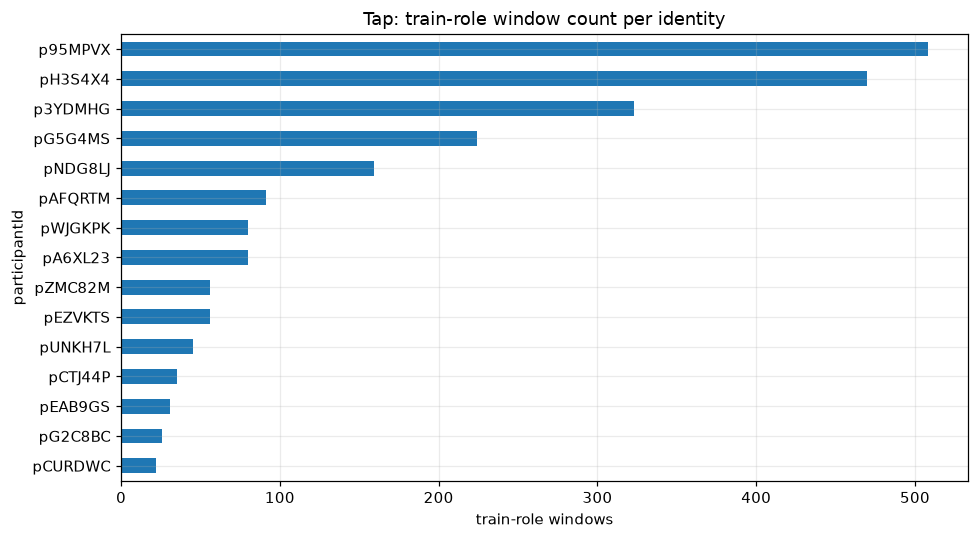


15 identities have train-role data, minimum 22 windows.


In [3]:
train_counts = df[df['role']=='train'].groupby('participantId').size().sort_values()
print(train_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
train_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('train-role windows'); ax.set_title('Tap: train-role window count per identity')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_train_windows_per_identity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{len(train_counts)} identities have train-role data, minimum {train_counts.min()} windows.")

## 3. Batch sampler and model

Architecture unchanged from the gesture notebook (P1's 256-128-32 MLP,
dropout 0.10, L2-normalised output, batch-all triplet loss, margin 0.20).
Same capped-batches-per-epoch speed fix and checkpoint cache as nb14.

In [4]:
IDENTITIES_PER_BATCH = 2
WINDOWS_PER_IDENTITY = 4
MARGIN = 0.20
EMBED_DIM = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_BATCHES_PER_EPOCH = 150

class BalancedIdentityBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels, identities_per_batch, windows_per_identity,
                 max_batches=MAX_BATCHES_PER_EPOCH, seed=0):
        self.by_identity = {pid: np.where(labels == pid)[0] for pid in np.unique(labels)}
        self.eligible = [pid for pid, idx in self.by_identity.items()
                          if len(idx) >= windows_per_identity]
        self.k, self.m = identities_per_batch, windows_per_identity
        self.rng = np.random.default_rng(seed)
        natural = max(1, sum(len(v) for v in self.by_identity.values()) // (self.k * self.m))
        self.n_batches = min(natural, max_batches)

    def __iter__(self):
        for _ in range(self.n_batches):
            pids = self.rng.choice(self.eligible, size=self.k, replace=False)
            batch = []
            for pid in pids:
                idx = self.by_identity[pid]
                chosen = self.rng.choice(idx, size=self.m, replace=len(idx) < self.m)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


class Embedder(nn.Module):
    def __init__(self, in_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        return nn.functional.normalize(self.net(x), p=2, dim=1)


def batch_all_triplet_loss(embeddings, labels, margin=MARGIN):
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.unsqueeze(0)
    same = (labels == labels.T)
    eye = torch.eye(len(labels[0]), dtype=torch.bool, device=embeddings.device)
    pos_mask, diff = same & ~eye, ~same

    losses = []
    for a in range(len(embeddings)):
        pos_d, neg_d = dist[a][pos_mask[a]], dist[a][diff[a]]
        if len(pos_d) == 0 or len(neg_d) == 0:
            continue
        l = torch.clamp(pos_d.unsqueeze(1) - neg_d.unsqueeze(0) + margin, min=0)
        losses.append(l.flatten())
    if not losses:
        return torch.tensor(0.0, requires_grad=True), 0.0
    all_losses = torch.cat(losses)
    active = all_losses[all_losses > 0]
    return all_losses.mean(), (active.numel() / max(all_losses.numel(), 1))

print(f"input dim {len(feats)}, embedding dim {EMBED_DIM}, "
      f"up to {MAX_BATCHES_PER_EPOCH} batches/epoch")

input dim 83, embedding dim 32, up to 150 batches/epoch


## 4. Training, with a checkpoint cache

Same `FORCE_RETRAIN = False` cache-by-data-fingerprint pattern as nb14.

In [5]:
FORCE_RETRAIN = True

def train_embedder(X, y, role, seed=0, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed)
    train_mask = role == 'train'
    X_train, y_train = X[train_mask], y[train_mask]
    model = Embedder(X.shape[1], EMBED_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sampler = BalancedIdentityBatchSampler(y_train, IDENTITIES_PER_BATCH, WINDOWS_PER_IDENTITY, seed=seed)
    history = {'epoch': [], 'loss': [], 'active_frac': []}
    for epoch in range(epochs):
        model.train()
        epoch_losses, epoch_actives = [], []
        for batch_idx in sampler:
            xb = torch.tensor(X_train[batch_idx])
            yb = torch.tensor(pd.factorize(y_train[batch_idx])[0])
            opt.zero_grad()
            emb = model(xb)
            loss, active_frac = batch_all_triplet_loss(emb, yb)
            loss.backward(); opt.step()
            epoch_losses.append(loss.item()); epoch_actives.append(active_frac)
        history['epoch'].append(epoch)
        history['loss'].append(np.mean(epoch_losses))
        history['active_frac'].append(np.mean(epoch_actives))
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:2d}  loss={history['loss'][-1]:.4f}  active_frac={history['active_frac'][-1]:.3f}")
    return model, pd.DataFrame(history)

fp = data_fingerprint()
ckpt_path = CKPT_DIR / f'primary_seed42_{fp}.pt'
if ckpt_path.exists() and not FORCE_RETRAIN:
    print(f"Loading cached model (fingerprint {fp}) -- set FORCE_RETRAIN=True to retrain.")
    ckpt = torch.load(ckpt_path, weights_only=False)
    model = Embedder(len(feats), EMBED_DIM)
    model.load_state_dict(ckpt['state_dict'])
    history = ckpt['history']
else:
    print("Training real-label model (seed=42)...")
    model, history = train_embedder(X_all, y_all, role_all, seed=42)
    torch.save({'state_dict': model.state_dict(), 'history': history}, ckpt_path)
    print(f"Cached to {ckpt_path.name}")

Training real-label model (seed=42)...
  epoch  0  loss=0.1476  active_frac=0.690
  epoch  5  loss=0.0922  active_frac=0.451
  epoch 10  loss=0.0724  active_frac=0.358
  epoch 15  loss=0.0609  active_frac=0.297
  epoch 20  loss=0.0484  active_frac=0.260
  epoch 25  loss=0.0462  active_frac=0.233
  epoch 30  loss=0.0402  active_frac=0.210
  epoch 35  loss=0.0250  active_frac=0.138
  epoch 39  loss=0.0365  active_frac=0.183
Cached to primary_seed42_186b17576ff5049c.pt


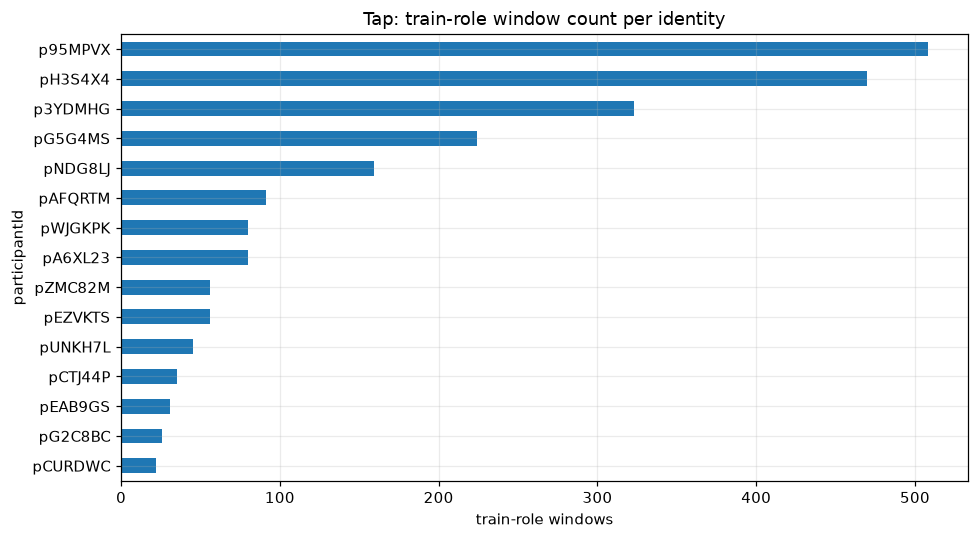

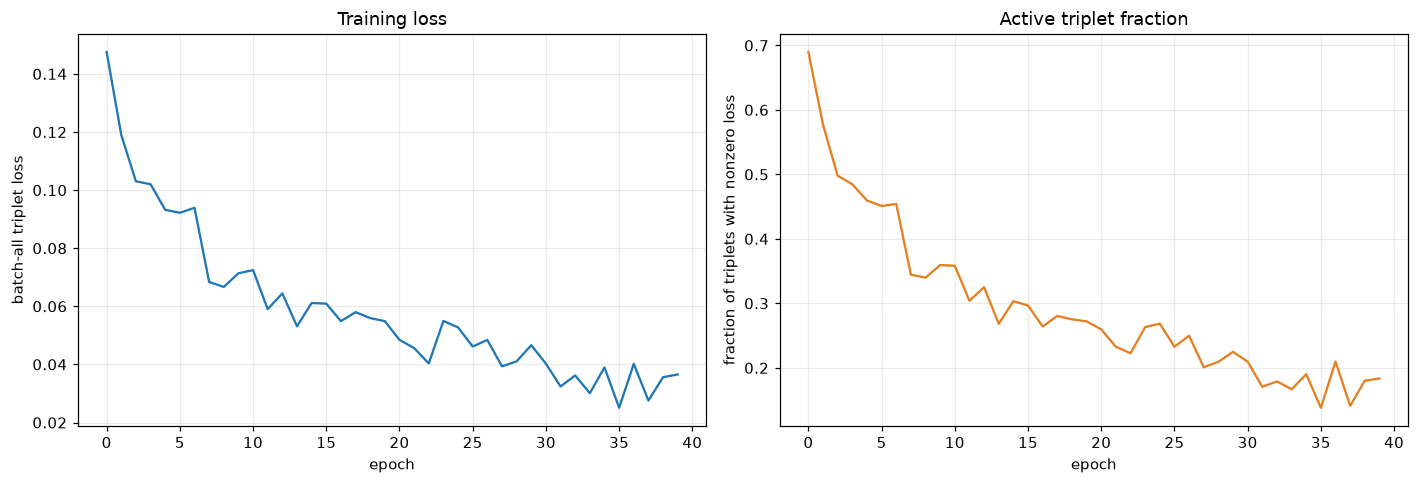

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['epoch'], history['loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('batch-all triplet loss'); axes[0].set_title('Training loss')
axes[1].plot(history['epoch'], history['active_frac'], color='#e67e22')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('fraction of triplets with nonzero loss')
axes[1].set_title('Active triplet fraction')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '02_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation -- fixed identity set

Same fixed-vs-all-available identity-set split as nb14, to avoid the
survivorship confound where the probe-identity set shrinks as k grows.

In [7]:
def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan, 'far_at_10pct_frr': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    eer = float((fpr[idx] + frr[idx]) / 2)
    far10 = float(np.interp(0.90, tpr, fpr))
    return {'auc': float(auc), 'eer': eer, 'far_at_10pct_frr': far10}

def embed(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X)).numpy()

def score_probe_windows(E, y, df_meta, role, k_values):
    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    refs = {pid: E[enrol_mask & (y == pid)].mean(axis=0) for pid in np.unique(y[enrol_mask])}
    rows = []
    for pid in np.unique(y[probe_mask]):
        idx = np.where(probe_mask & (y == pid))[0]
        order = np.argsort(df_meta.loc[idx, 'window_start_s'].values)
        Ep = E[idx[order]]
        for k in k_values:
            if len(Ep) < k: continue
            for i in range(len(Ep) - k + 1):
                agg = Ep[i:i+k].mean(axis=0)
                for cand, ref in refs.items():
                    rows.append({'k': k, 'pid': pid, 'cand': cand, 'genuine': int(cand == pid),
                                 'dist': float(np.linalg.norm(agg - ref)),
                                 'trust_id': f'{pid}|{i}|{k}'})
    return pd.DataFrame(rows), refs

def summarise(scored, fixed_identities=None, label=''):
    if fixed_identities is not None:
        scored = scored[scored['pid'].isin(fixed_identities)]
    per_k, per_identity = [], []
    for k, g in scored.groupby('k'):
        g = g.copy()
        g['z'] = g.groupby('trust_id')['dist'].transform(
            lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        per_k.append({'k': k, 'identity_set': label, 'n_probe_identities': g['pid'].nunique(),
                       'n_trust_windows': g['trust_id'].nunique(),
                       **compute_metrics(g['genuine'], -g['z'])})
        for pid, gp in g.groupby('pid'):
            if gp['genuine'].nunique() < 2: continue
            per_identity.append({'k': k, 'identity_set': label, 'participantId': pid,
                                  'auc': roc_auc_score(gp['genuine'], -gp['z']),
                                  'n_comparisons': len(gp)})
    return pd.DataFrame(per_k), pd.DataFrame(per_identity)

k_values = [1, 2, 3, 5, 8, 10, 15, 20]
E_all = embed(model, X_all)
df_idx = df.reset_index(drop=True)
scored, refs = score_probe_windows(E_all, y_all, df_idx, role_all, k_values)
print(f"{len(refs)} reference identities, {len(scored)} scored rows")

res_all, per_id_all = summarise(scored, fixed_identities=None, label='all_available')

max_k = max(k_values)
probe_counts = df_idx[df_idx['role']=='probe'].groupby('participantId').size()
fixed_identities = set(probe_counts[probe_counts >= max_k].index) & set(refs.keys())
print(f"{len(fixed_identities)} identities have >= {max_k} probe windows: {sorted(fixed_identities)}")

if len(fixed_identities) >= 2:
    res_fixed, per_id_fixed = summarise(scored, fixed_identities=fixed_identities, label='fixed_across_k')
else:
    print("WARNING: fewer than 2 identities qualify for the fixed set -- reporting all_available only.")
    res_fixed, per_id_fixed = res_all.copy(), per_id_all.copy()

res_df = pd.concat([res_all, res_fixed], ignore_index=True)
per_id_df = pd.concat([per_id_all, per_id_fixed], ignore_index=True)
print()
print(res_df[res_df['identity_set']=='fixed_across_k']
      [['k','n_probe_identities','auc','eer']].to_string(index=False, float_format=lambda v:f'{v:.3f}'))

12 reference identities, 25500 scored rows
8 identities have >= 20 probe windows: ['p3M6E7Z', 'p3YDMHG', 'p95MPVX', 'pAFQRTM', 'pH3S4X4', 'pNDG8LJ', 'pUNKH7L', 'pWS9VTN']

 k  n_probe_identities   auc   eer
 1                   8 0.820 0.248
 2                   8 0.840 0.212
 3                   8 0.854 0.204
 5                   8 0.870 0.175
 8                   8 0.890 0.159
10                   8 0.901 0.151
15                   8 0.920 0.132
20                   8 0.944 0.098


## 6. Trained embedder vs raw-distance baseline

`BASELINE_AUC` here is pulled from `trust_window_results.csv`'s tap /
`fixed_across_k` / `auc_cohort_norm` rows (post harness fix, post
tailmean revert) -- NOT copied from the gesture notebook. Refresh this
dict from a fresh `evaluate_trust_windows.py` run if the underlying data
changes again.

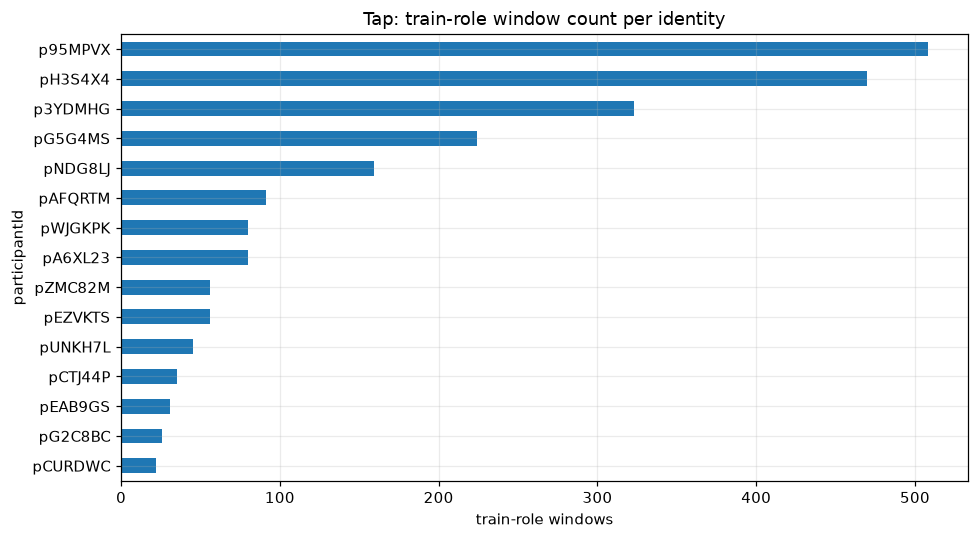

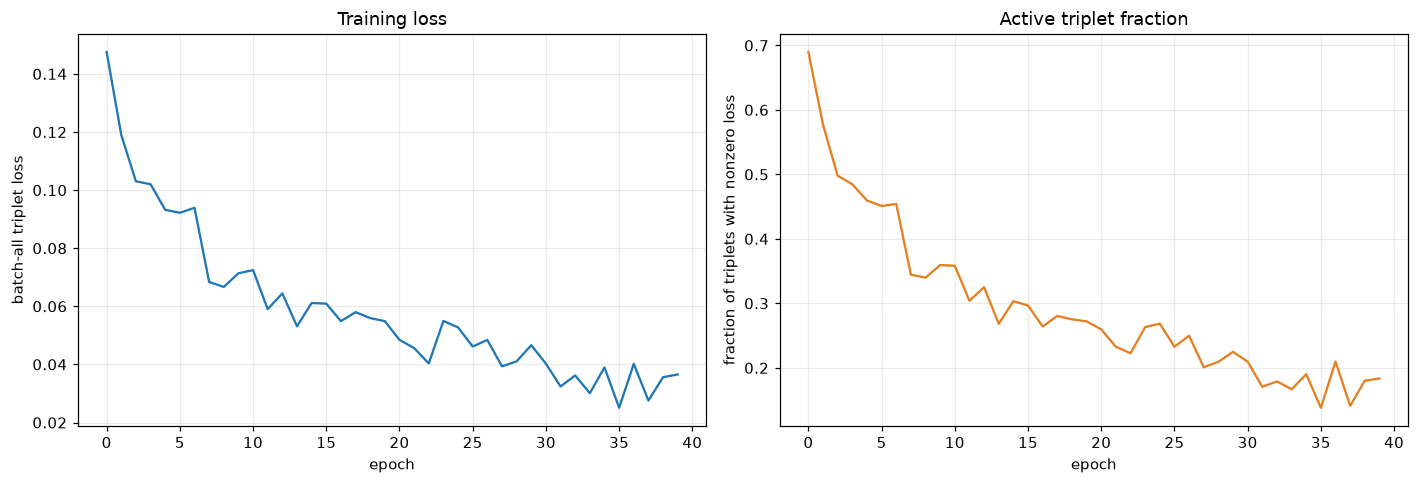

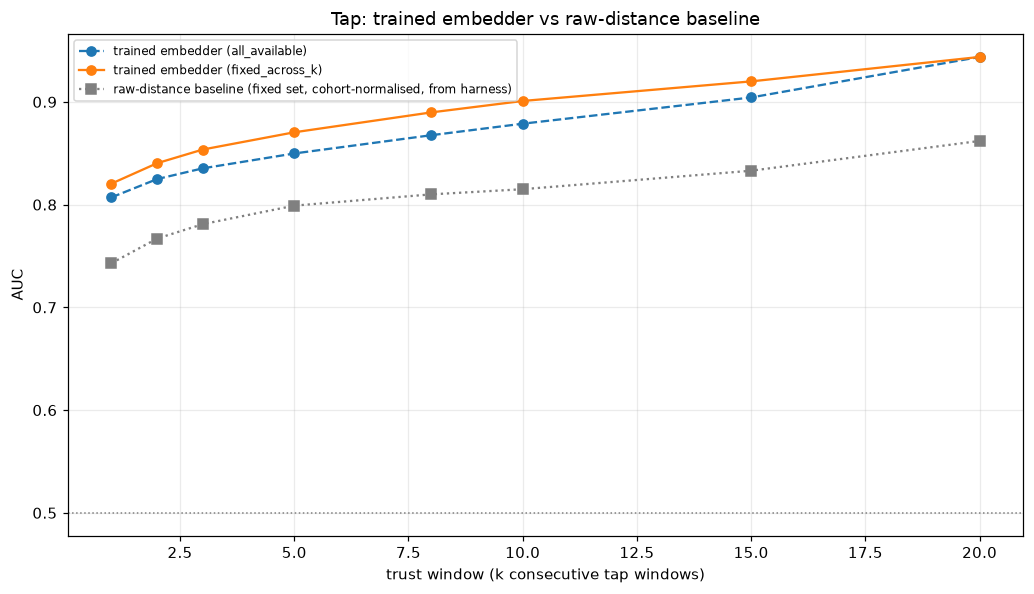

AUC at k=20, all_available minus fixed_across_k: +0.000 (positive means the earlier, unfixed curve was inflated by identity dropout)
k= 1: embedder 0.820 vs baseline 0.743 (+0.077)
k= 2: embedder 0.840 vs baseline 0.767 (+0.073)
k= 3: embedder 0.854 vs baseline 0.781 (+0.073)
k= 5: embedder 0.870 vs baseline 0.799 (+0.071)
k= 8: embedder 0.890 vs baseline 0.810 (+0.080)
k=10: embedder 0.901 vs baseline 0.815 (+0.086)
k=15: embedder 0.920 vs baseline 0.833 (+0.087)
k=20: embedder 0.944 vs baseline 0.862 (+0.082)


In [8]:
BASELINE_AUC = {1: 0.743, 2: 0.767, 3: 0.781, 5: 0.799, 8: 0.810, 10: 0.815, 15: 0.833, 20: 0.862}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, style in [('all_available', '--'), ('fixed_across_k', '-')]:
    sub = res_df[res_df['identity_set']==label].sort_values('k')
    ax.plot(sub['k'], sub['auc'], marker='o', ls=style, label=f'trained embedder ({label})')
bl_k = [k for k in k_values if k in BASELINE_AUC]
ax.plot(bl_k, [BASELINE_AUC[k] for k in bl_k], marker='s', ls=':', color='gray',
        label='raw-distance baseline (fixed set, cohort-normalised, from harness)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('trust window (k consecutive tap windows)'); ax.set_ylabel('AUC')
ax.set_title('Tap: trained embedder vs raw-distance baseline')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '03_embedder_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

drop_at_20 = res_df[(res_df['identity_set']=='all_available')&(res_df['k']==20)]['auc'].iloc[0] - \
             res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==20)]['auc'].iloc[0]
print(f"AUC at k=20, all_available minus fixed_across_k: {drop_at_20:+.3f} "
      f"(positive means the earlier, unfixed curve was inflated by identity dropout)")

for k in bl_k:
    trained = res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==k)]['auc']
    if len(trained):
        print(f"k={k:2d}: embedder {trained.iloc[0]:.3f} vs baseline {BASELINE_AUC[k]:.3f} "
              f"({trained.iloc[0]-BASELINE_AUC[k]:+.3f})")

## 7. Multi-seed stability (fixed identity set)

In [9]:
SEEDS = [7, 13, 42]
seed_results = []
for seed in SEEDS:
    print(f"seed {seed}...")
    ckpt_s = CKPT_DIR / f'seed{seed}_{fp}.pt'
    if ckpt_s.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_s, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_all, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_s)
    Es = embed(m, X_all)
    sc, _ = score_probe_windows(Es, y_all, df_idx, role_all, [1, 10, 20])
    rk, _ = summarise(sc, fixed_identities=fixed_identities, label='fixed_across_k')
    rk['seed'] = seed
    seed_results.append(rk)

seed_df = pd.concat(seed_results, ignore_index=True)
summary = seed_df.groupby('k')['auc'].agg(['mean', 'std'])
print(summary.round(3).to_string())

seed 7...
seed 13...
seed 42...
     mean    std
k               
1   0.826  0.005
10  0.905  0.004
20  0.948  0.005


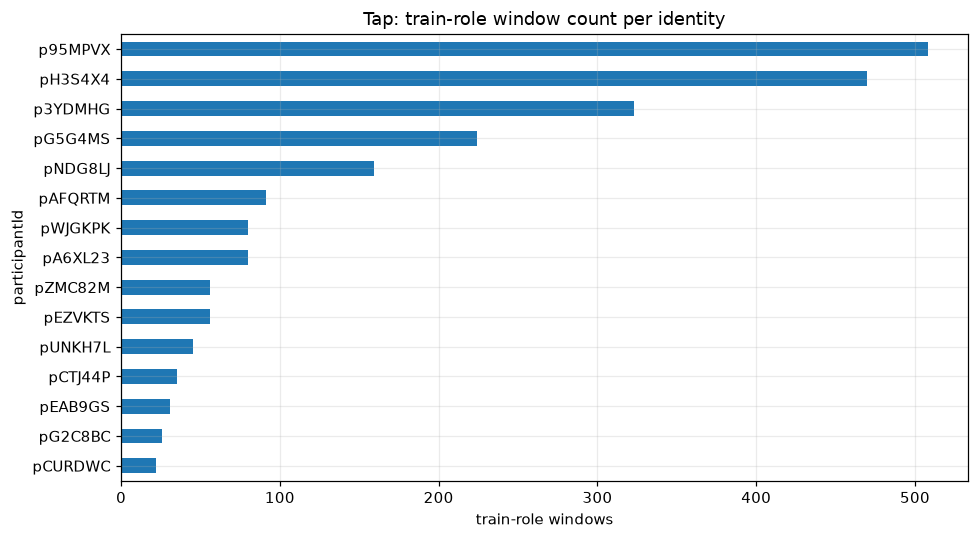

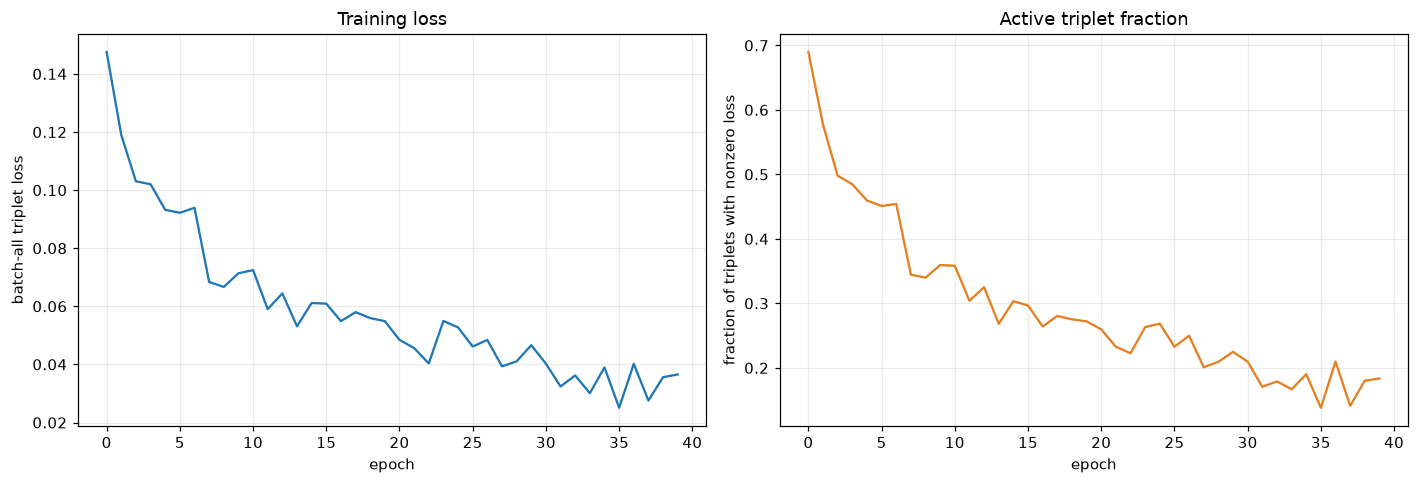

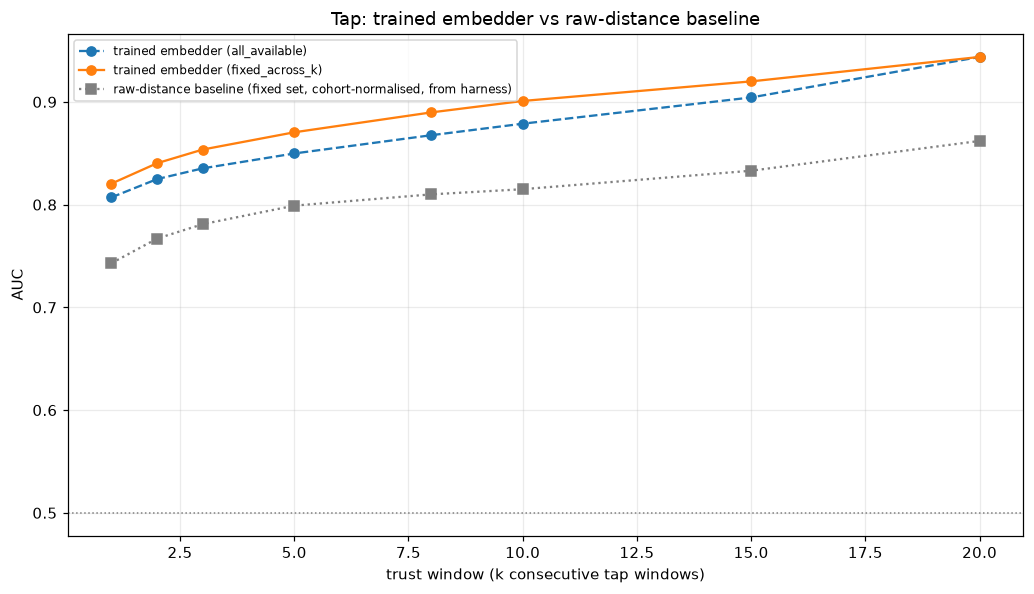

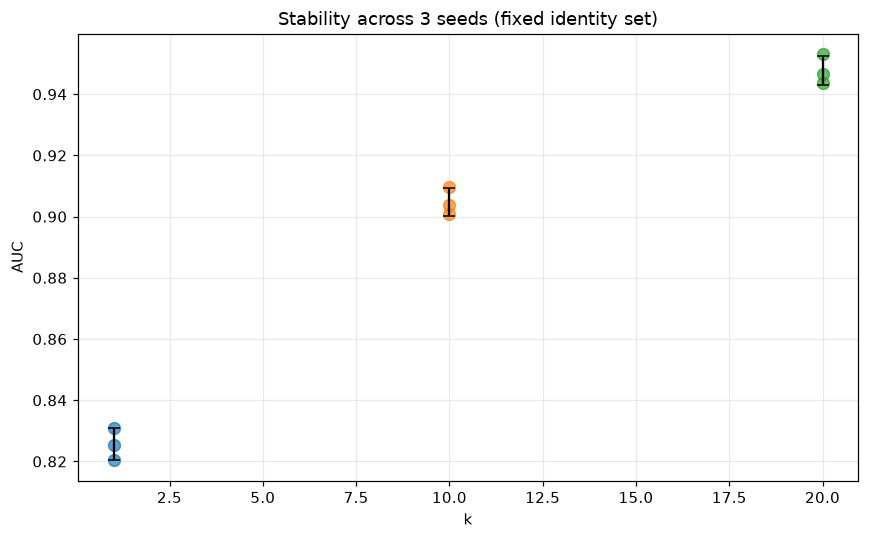

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in seed_df['k'].unique():
    vals = seed_df[seed_df['k']==k]['auc']
    ax.scatter([k]*len(vals), vals, alpha=0.7, s=60)
ax.errorbar(summary.index, summary['mean'], yerr=summary['std'], fmt='none', color='k', capsize=4)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title(f'Stability across {len(SEEDS)} seeds (fixed identity set)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '04_seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Negative control -- trained model, fixed identity set

In [11]:
def shuffle_labels(y, df_meta, seed):
    rng = np.random.default_rng(seed)
    sess_pid = df_meta.groupby('sessionId')['participantId'].first()
    mapping = dict(zip(sess_pid.index, rng.permutation(sess_pid.values)))
    return df_meta['sessionId'].map(mapping).values

control_results = []
for seed in [0, 1, 2]:
    y_shuf = shuffle_labels(y_all, df_idx, seed)
    ckpt_c = CKPT_DIR / f'control{seed}_{fp}.pt'
    if ckpt_c.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_c, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_shuf, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_c)
    Ec = embed(m, X_all)
    sc, _ = score_probe_windows(Ec, y_shuf, df_idx, role_all, [1, 10, 20])
    rk, _ = summarise(sc, fixed_identities=fixed_identities, label='fixed_across_k')
    rk['seed'] = seed
    control_results.append(rk)

control_df = pd.concat(control_results, ignore_index=True)
ctrl_summary = control_df.groupby('k')['auc'].agg(['mean', 'std'])
print("shuffled-label control:"); print(ctrl_summary.round(3).to_string())
compare = summary[['mean']].join(ctrl_summary[['mean']], lsuffix='_real', rsuffix='_shuffled')
compare['gap'] = compare['mean_real'] - compare['mean_shuffled']
print(); print(compare.round(3).to_string())

shuffled-label control:
     mean    std
k               
1   0.483  0.152
10  0.426  0.216
20  0.385  0.218

    mean_real  mean_shuffled    gap
k                                  
1       0.826          0.483  0.342
10      0.905          0.426  0.479
20      0.948          0.385  0.563


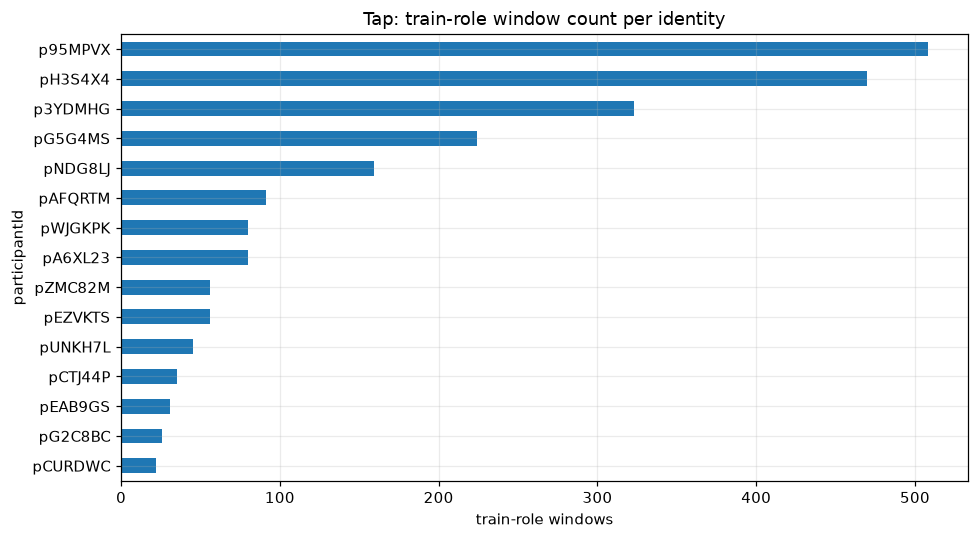

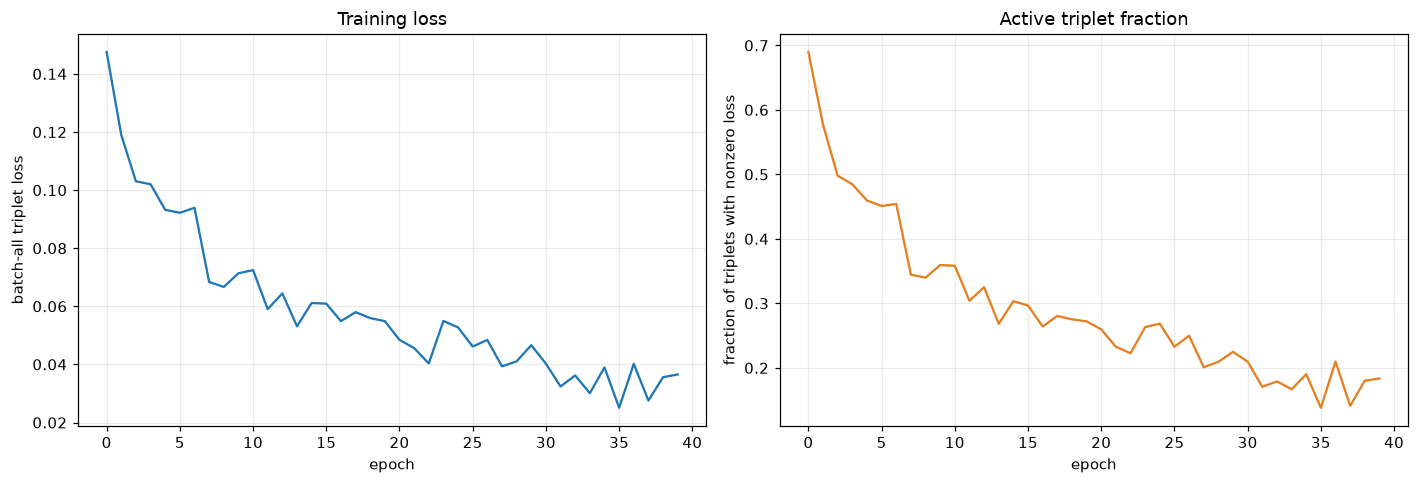

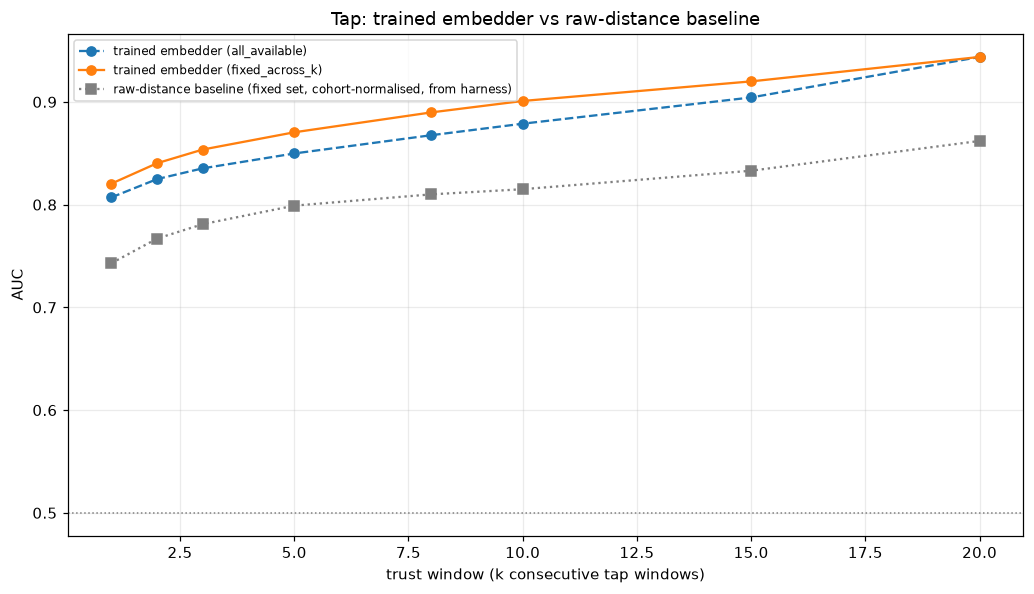

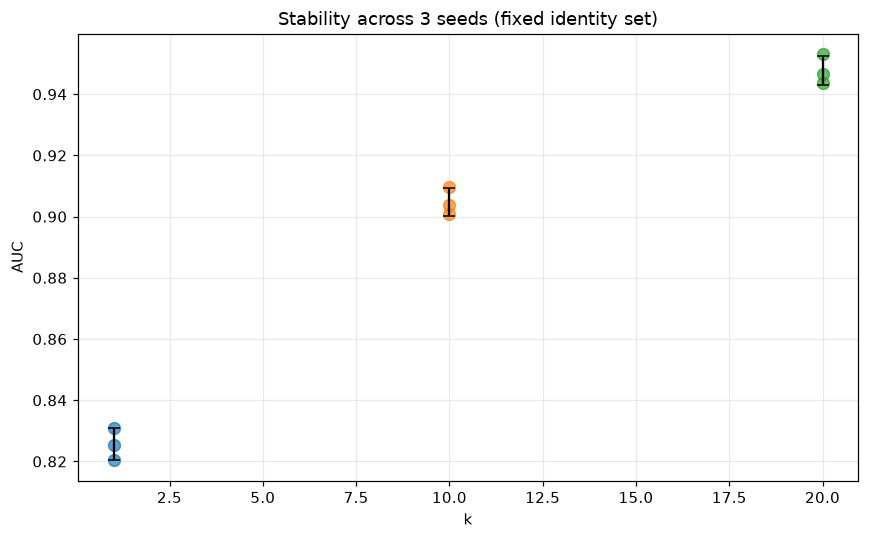

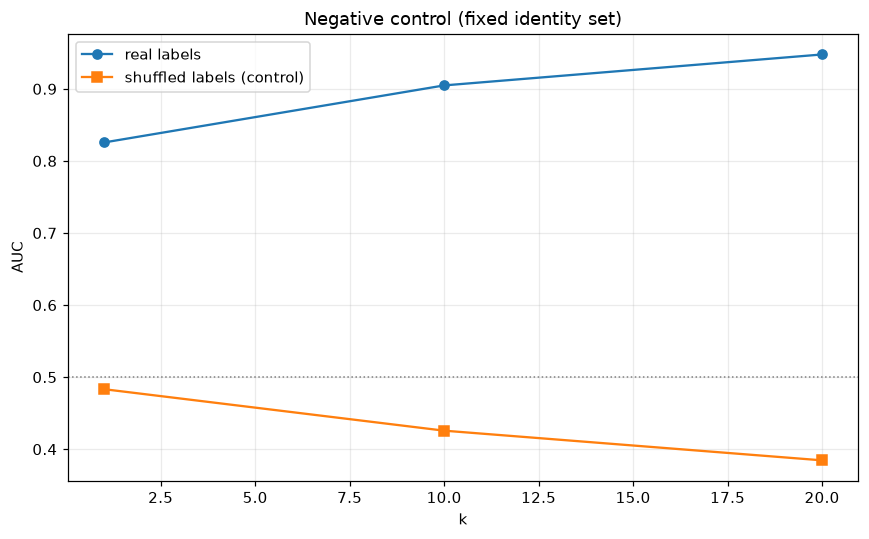

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary.index, summary['mean'], marker='o', label='real labels')
ax.plot(ctrl_summary.index, ctrl_summary['mean'], marker='s', label='shuffled labels (control)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title('Negative control (fixed identity set)')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / '05_negative_control.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Permutation feature importance

Same method as nb14: shuffle one feature at a time across probe windows,
recompute embeddings with the already-trained model, measure the AUC drop
at k=1 -- model-agnostic, no retraining needed.

In [13]:
rng = np.random.default_rng(0)
probe_mask = role_all == 'probe'
baseline_scored, _ = score_probe_windows(E_all, y_all, df_idx, role_all, [1])
baseline_res, _ = summarise(baseline_scored, fixed_identities=fixed_identities, label='fixed_across_k')
baseline_auc = baseline_res.loc[baseline_res['k']==1, 'auc'].iloc[0]
print(f"baseline (unpermuted) AUC at k=1: {baseline_auc:.3f}")

importances = []
X_perm_base = X_all.copy()
for j, feat_name in enumerate(feats):
    X_perm = X_perm_base.copy()
    perm_idx = rng.permutation(np.where(probe_mask)[0])
    X_perm[np.where(probe_mask)[0], j] = X_perm_base[perm_idx, j]
    E_perm = embed(model, X_perm)
    sc_perm, _ = score_probe_windows(E_perm, y_all, df_idx, role_all, [1])
    res_perm, _ = summarise(sc_perm, fixed_identities=fixed_identities, label='fixed_across_k')
    perm_auc = res_perm.loc[res_perm['k']==1, 'auc'].iloc[0] if len(res_perm) else np.nan
    importances.append({'feature': feat_name, 'auc_drop': baseline_auc - perm_auc})

importance_df = pd.DataFrame(importances).sort_values('auc_drop', ascending=False)
print(importance_df.head(15).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

baseline (unpermuted) AUC at k=1: 0.820
                                     feature  auc_drop
                coupling_tap_accel_peak_mean    0.0152
      coupling_tap_orient_gamma_peak_dev_std    0.0117
              coupling_tap_accel_peak_median    0.0101
                                   tap_x_max    0.0083
                                  tap_x_mean    0.0070
      coupling_tap_orient_gamma_peak_dev_iqr    0.0064
                                   tap_x_p95    0.0057
                                  tap_y_mean    0.0055
     coupling_tap_orient_beta_peak_dev_slope    0.0054
                                   tap_x_iqr    0.0053
                                    tap_x_cv    0.0051
coupling_tap_orient_beta_peak_latency_ms_iqr    0.0049
          coupling_tap_accel_decay_ratio_p95    0.0048
           coupling_tap_accel_latency_ms_iqr    0.0041
                                tap_y_median    0.0039


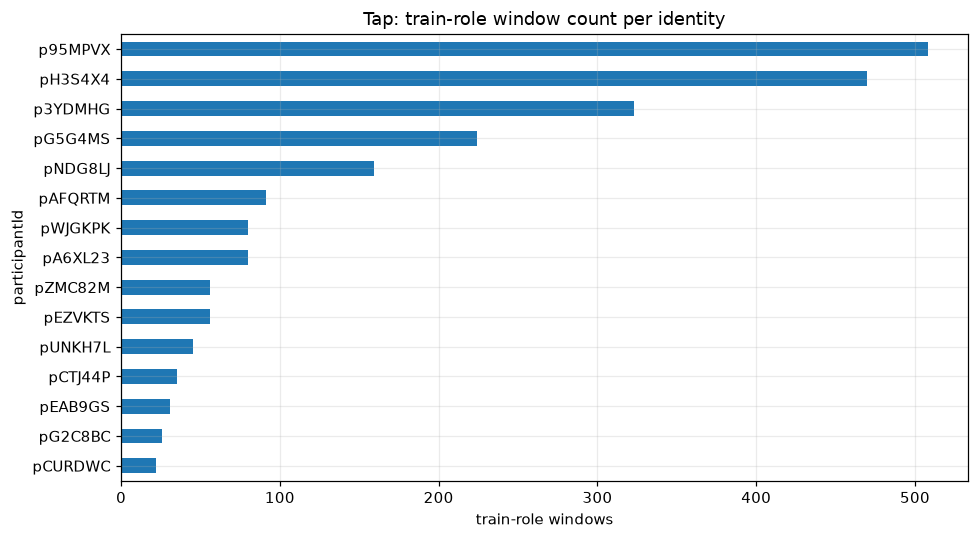

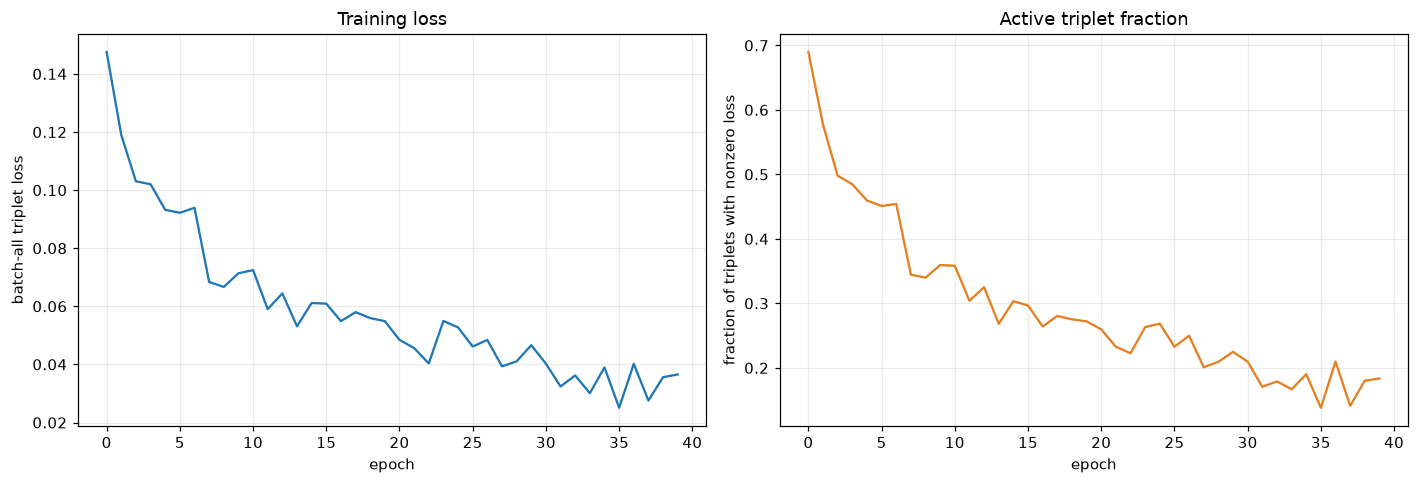

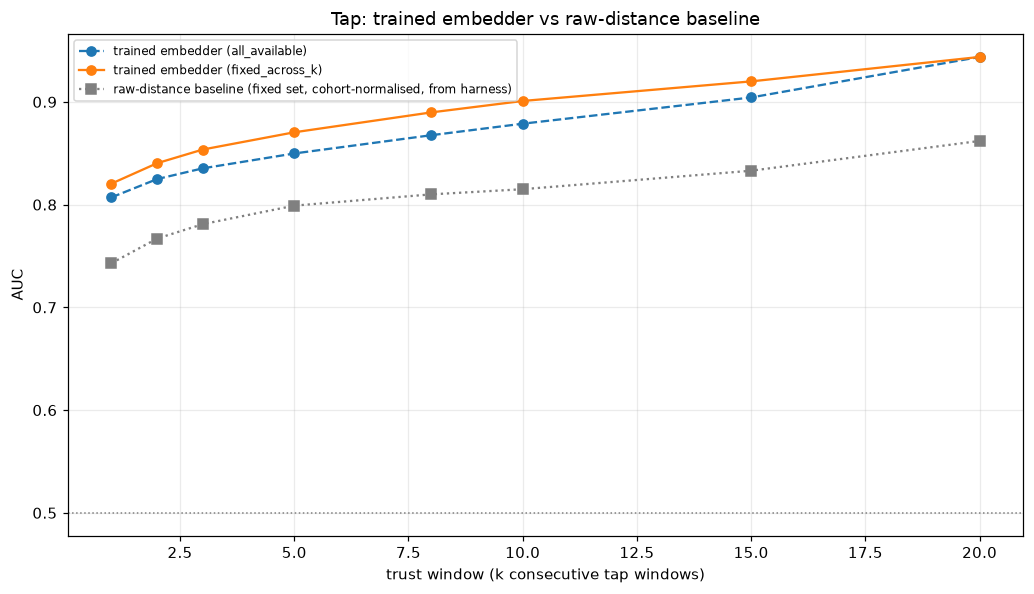

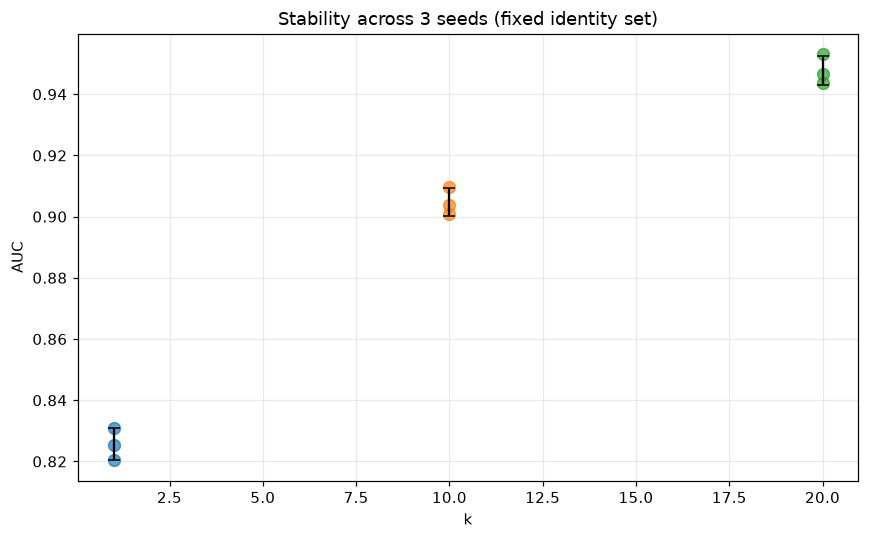

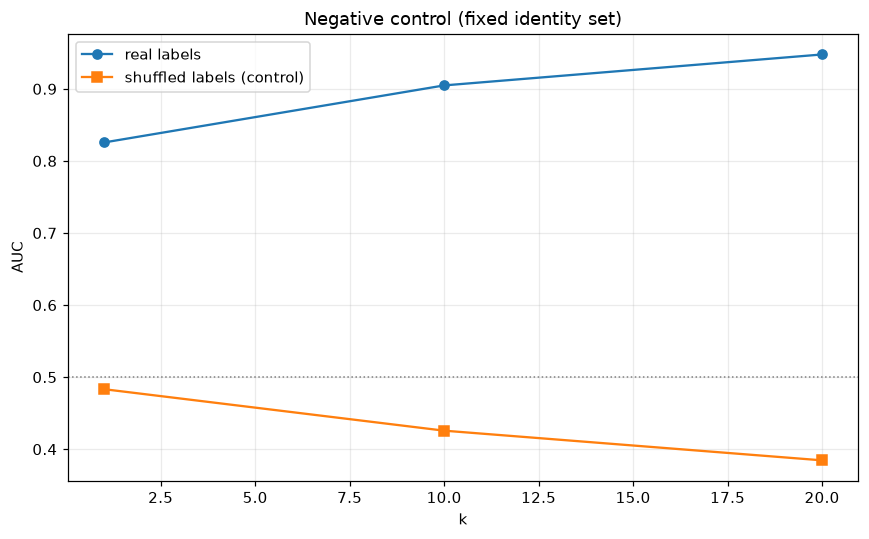

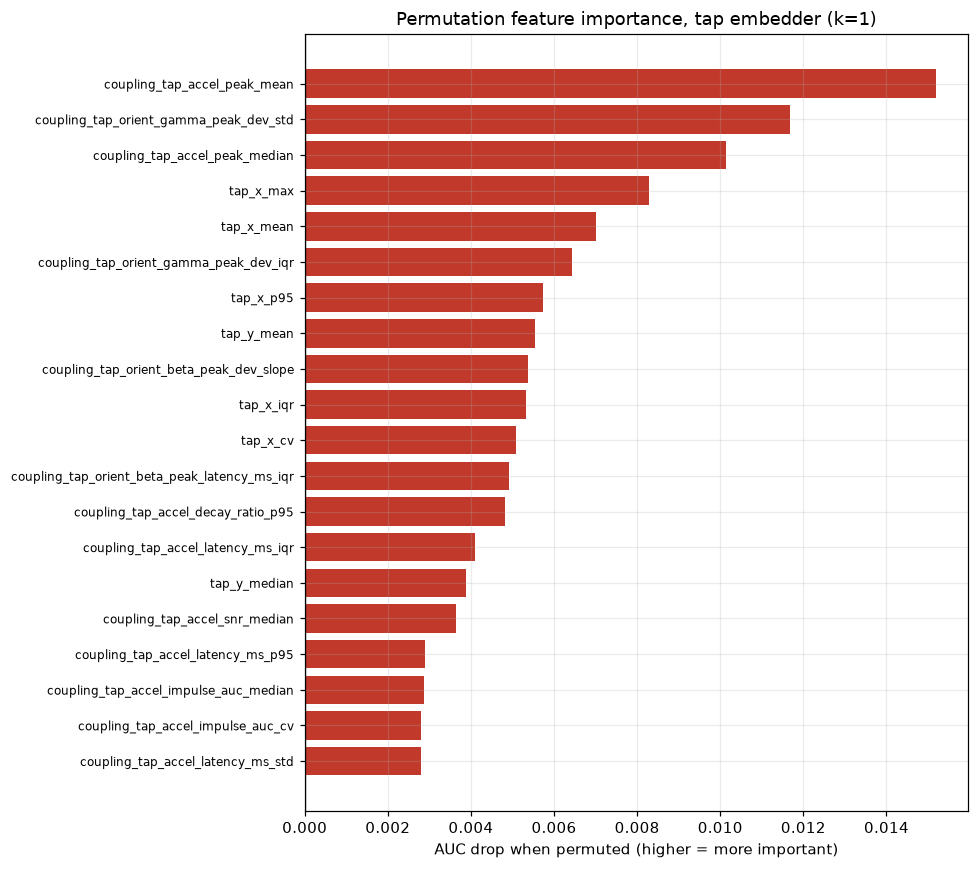

In [14]:
fig, ax = plt.subplots(figsize=(9, 8))
top = importance_df.head(20).iloc[::-1]
ax.barh(range(len(top)), top['auc_drop'], color=['#c0392b' if v > 0 else '#7f8c8d' for v in top['auc_drop']])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['feature'], fontsize=8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('AUC drop when permuted (higher = more important)')
ax.set_title('Permutation feature importance, tap embedder (k=1)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

n_negative = (importance_df['auc_drop'] < -0.005).sum()
if n_negative:
    print(f"\nNOTE: {n_negative} feature(s) show a NEGATIVE auc_drop (performance improved when "
          f"permuted, i.e. removing their real signal helped) -- worth checking whether these are "
          f"adding noise rather than signal, candidates for exclusion in a future feature-set pass.")

## 10. Embedding space, qualitatively

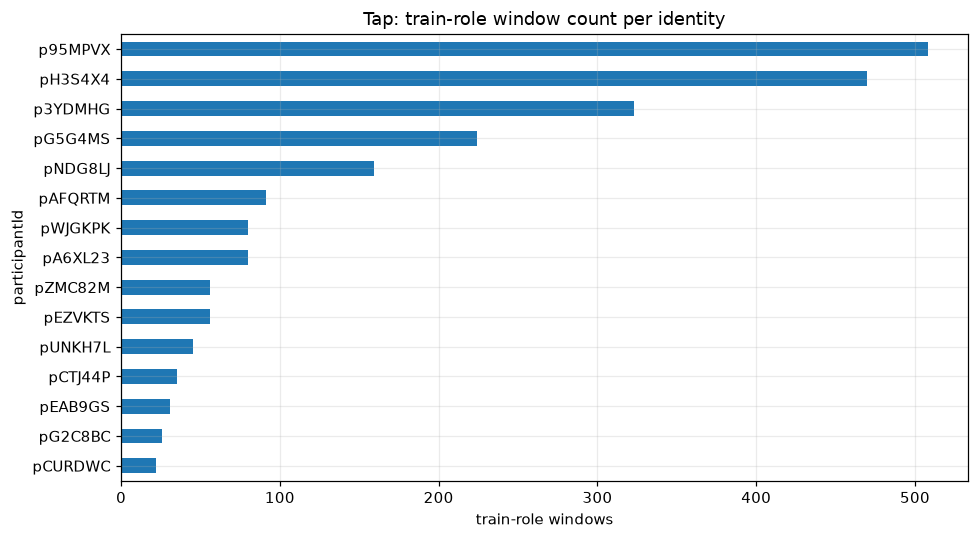

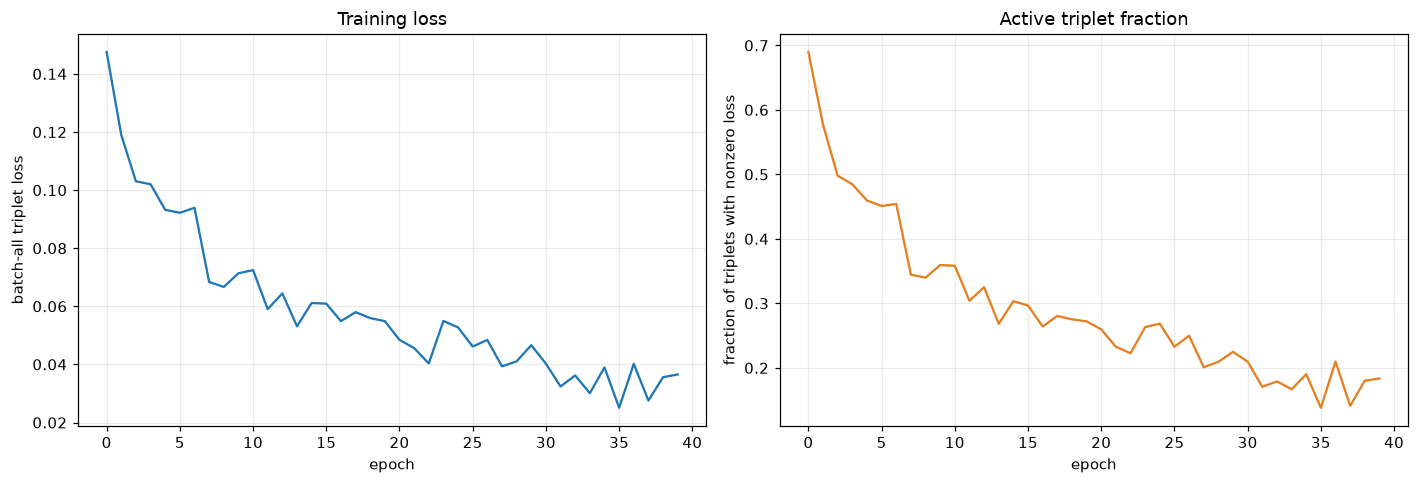

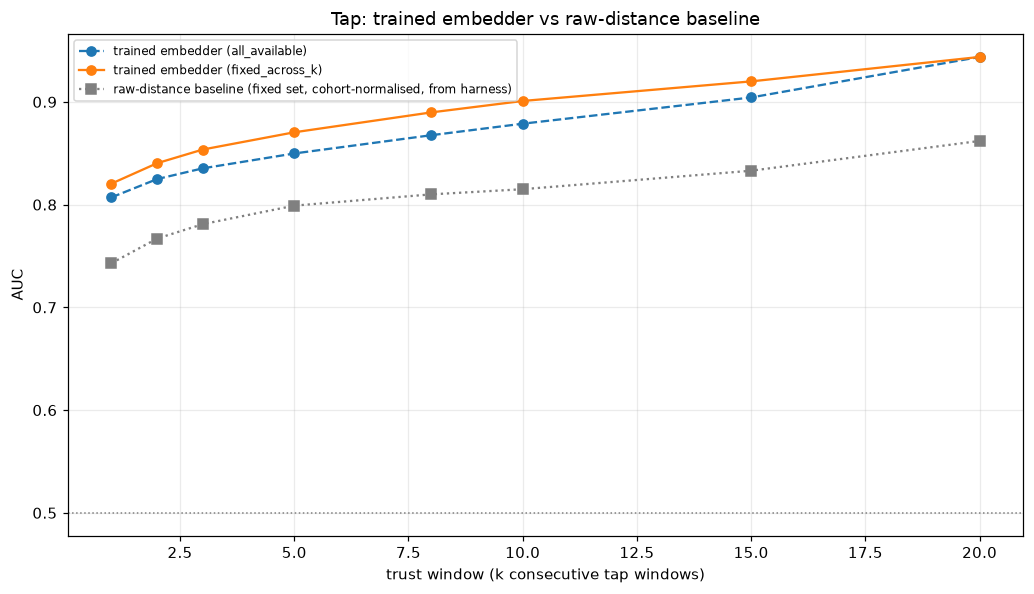

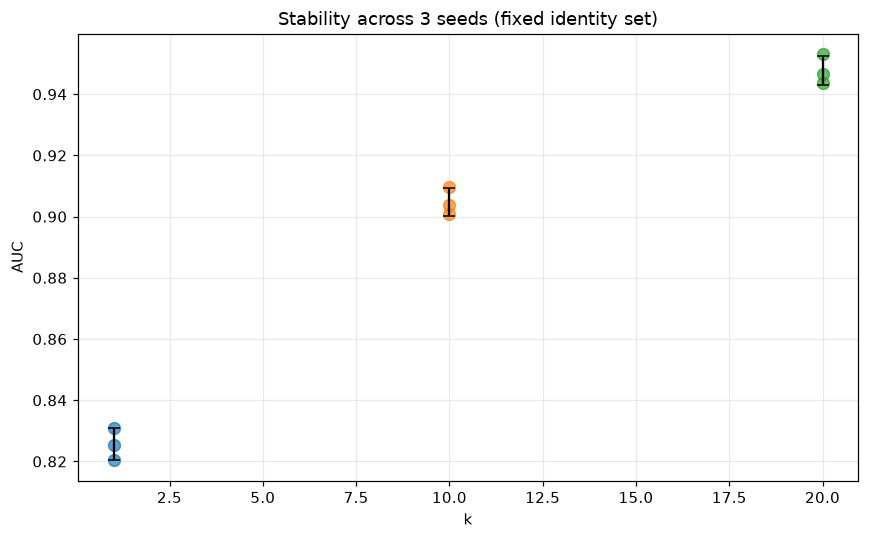

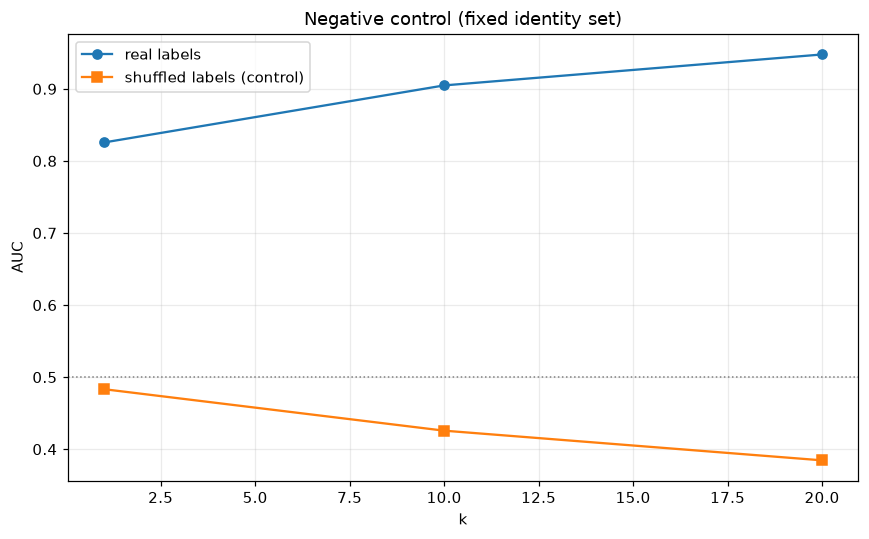

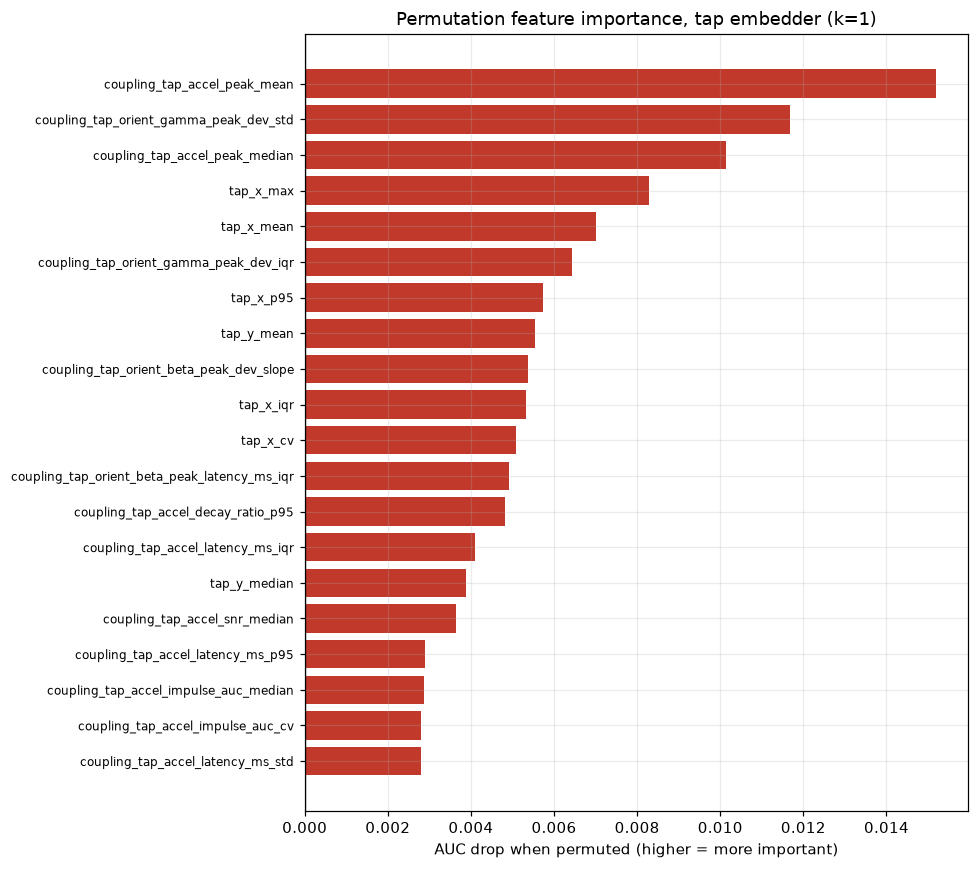

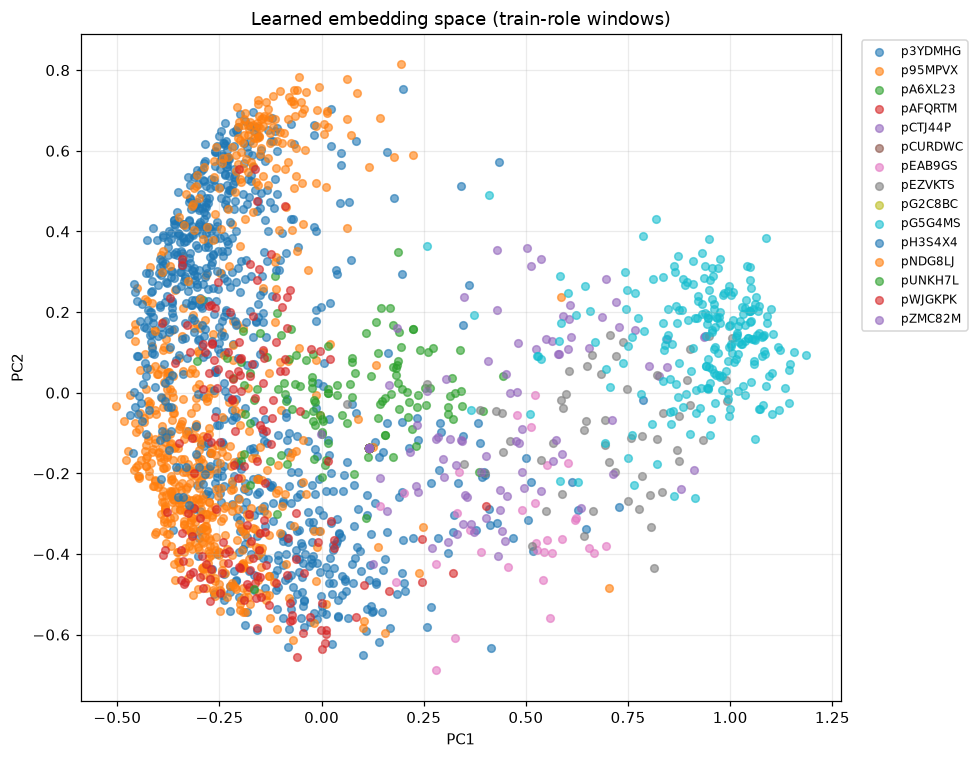

explained variance (first 2 PCs): [0.29  0.187]


In [15]:
with torch.no_grad():
    E_train = embed(model, X_all[role_all == 'train'])
y_train_plot = y_all[role_all == 'train']

pca = PCA(n_components=2).fit(E_train)
E2 = pca.transform(E_train)

fig, ax = plt.subplots(figsize=(9, 7))
for pid in np.unique(y_train_plot):
    m = y_train_plot == pid
    ax.scatter(E2[m, 0], E2[m, 1], label=pid, alpha=0.6, s=25)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Learned embedding space (train-role windows)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '06_embedding_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"explained variance (first 2 PCs): {pca.explained_variance_ratio_.round(3)}")

## 11. Export

In [16]:
import json as _json
from datetime import datetime, timezone

res_df.to_csv(OUT_DIR / 'trained_vs_baseline.csv', index=False)
per_id_df.to_csv(OUT_DIR / 'per_participant.csv', index=False)
seed_df.to_csv(OUT_DIR / 'seed_stability_raw.csv', index=False)
summary.reset_index().to_csv(OUT_DIR / 'seed_stability_summary.csv', index=False)
control_df.to_csv(OUT_DIR / 'negative_control_raw.csv', index=False)
compare.reset_index().to_csv(OUT_DIR / 'negative_control_summary.csv', index=False)
history.to_csv(OUT_DIR / 'training_history_seed42.csv', index=False)
importance_df.to_csv(OUT_DIR / 'feature_importance.csv', index=False)

torch.save({'state_dict': model.state_dict(), 'feature_names': feats, 'embed_dim': EMBED_DIM},
           OUT_DIR / 'model_seed42.pt')
np.savez(OUT_DIR / 'preprocessing.npz', impute_values=imputer.statistics_,
         scale_mean=scaler.mean_, scale_scale=scaler.scale_,
         feature_names=np.array(feats, dtype=object))

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'modality': 'tap', 'data_fingerprint': fp,
    'n_windows': int(len(df)), 'n_features': len(feats),
    'n_reference_identities': len(refs), 'n_fixed_identities': len(fixed_identities),
    'fixed_identities': sorted(fixed_identities),
    'architecture': '256-128-32 MLP, dropout 0.10, L2-normalised output',
    'max_batches_per_epoch': MAX_BATCHES_PER_EPOCH, 'epochs': EPOCHS, 'seeds_run': SEEDS,
    'baseline_source': 'trust_window_results.csv, tap/fixed_across_k/auc_cohort_norm',
    'auc_real_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in summary['mean'].items()},
    'auc_shuffled_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in ctrl_summary['mean'].items()},
    'files': sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()) +
             ['plots/' + p.name for p in PLOTS_DIR.iterdir()],
}
with open(OUT_DIR / 'manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")

Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/ML-notebooks:
  .DS_Store  (6.0 KB)
  14_gesture_embedder.ipynb  (2037.2 KB)
  15_tap_embedder.ipynb  (2223.9 KB)
  checkpoints/control0_186b17576ff5049c.pt  (231.6 KB)
  checkpoints/control1_186b17576ff5049c.pt  (231.6 KB)
  checkpoints/control2_186b17576ff5049c.pt  (231.6 KB)
  checkpoints/primary_seed42_186b17576ff5049c.pt  (233.8 KB)
  checkpoints/seed13_186b17576ff5049c.pt  (231.5 KB)
  checkpoints/seed42_186b17576ff5049c.pt  (231.5 KB)
  checkpoints/seed7_186b17576ff5049c.pt  (231.5 KB)
  feature_importance.csv  (4.4 KB)
  manifest.json  (1.4 KB)
  model_seed42.pt  (234.4 KB)
  negative_control_raw.csv  (0.8 KB)
  negative_control_summary.csv  (0.2 KB)
  per_participant.csv  (6.8 KB)
  plots/01_train_windows_per_identity.png  (52.6 KB)
  plots/02_training_curves.png  (90.7 KB)
  plots/03_embedder_vs_baseline.png  (68.7 KB)
  plots/04_seed_stability.png  (34.5 KB)
  plots/05_negative_control.png  (41.5 KB)
  plots/06_embeddi

## How to avoid the wait on repeat runs

Same guidance as nb14: don't Restart & Run All unless something upstream
changed; `FORCE_RETRAIN = False` reloads all 7 trained models from
`checkpoints/` keyed on a data/feature/role fingerprint; lower
`MAX_BATCHES_PER_EPOCH` for a quick sanity check while iterating on
unrelated cells; Sections 7-8 are 6 of the 7 total trainings, so comment
out seeds/controls you don't need while iterating on something else.